# Vtora laboratoriska vezba


In [135]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np 
import pandas as pd
from sklearn.metrics import accuracy_score
from scipy import stats 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import BayesianRidge


from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # За евалуација на модели
data = pd.read_csv('Student_Performance.csv')
rows = data.values
features = []
y = np.array( [i[-1] for i in rows])

#Yes ke stane 1, No ke stane 0 so cel da bidat numericski
for i in rows:
    li = []
    for j in i[:-1]:
        if j == 'Yes':
            li.append(1)
        elif j == 'No':
            li.append(0)
        else:
            li.append(j)
   

    features.append(li)
X =np.array(features) 
print('Targets: ',y)
print('Features:\n', X)

data.head(10)
feature_names = ['Hours Studied','Previous Scores','Extracurricular Activities',
                  'Sleep Hours','Sample Question Papers Practiced',
                 ]




Targets:  [91. 65. 45. ... 74. 95. 64.]
Features:
 [[ 7 99  1  9  1]
 [ 4 82  0  4  2]
 [ 8 51  1  7  2]
 ...
 [ 6 83  1  8  5]
 [ 9 97  1  7  0]
 [ 7 74  0  8  1]]


In [136]:
number_of_features = 5
instances = data.shape[0]
print('Broj na instanci', instances)
print('Number of features:', number_of_features)
data.head(10)

Broj na instanci 10000
Number of features: 5


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0
8,5,77,No,8,2,61.0
9,4,89,No,4,0,69.0


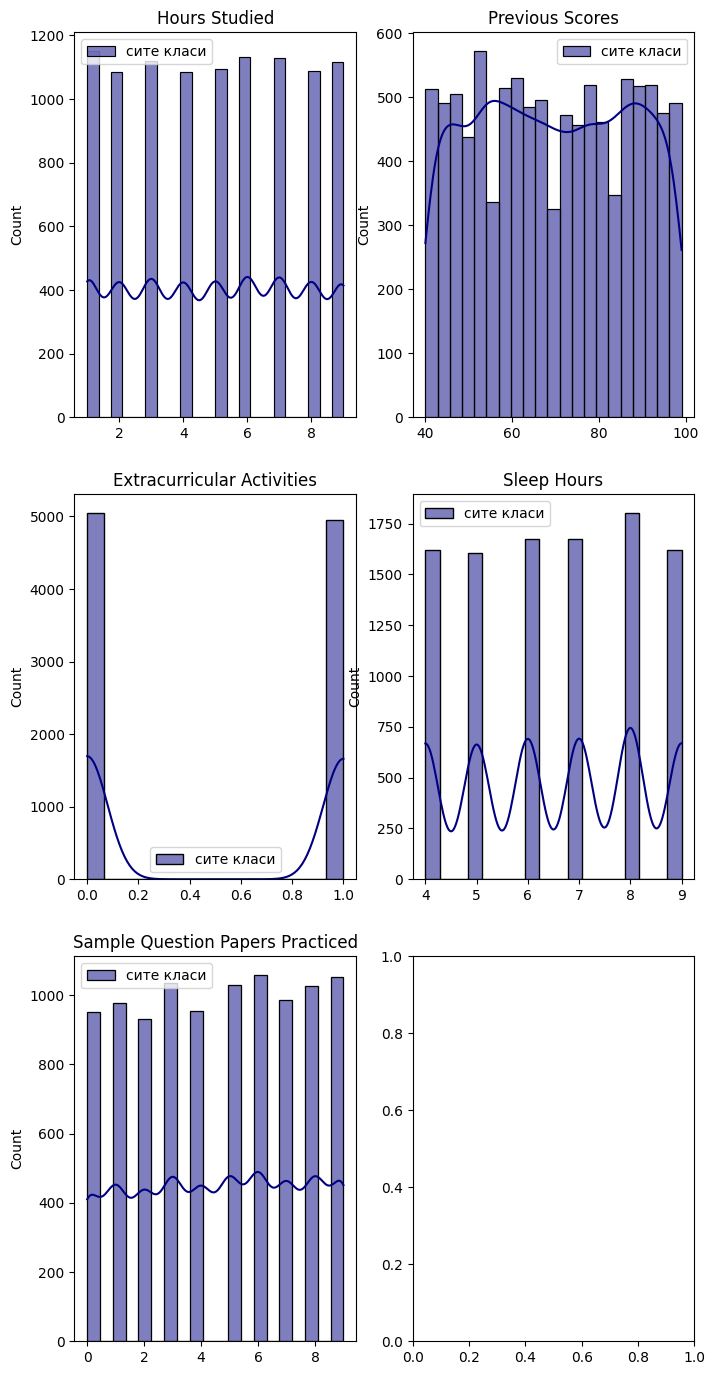

In [137]:

fig = plt.figure(figsize=(8, 17))
fig.subplots(nrows=3, ncols=2)
for feat_i in range(number_of_features): #хистограми за секој атрибут
    ax = plt.subplot(3,2, feat_i+1)
    plt.title(feature_names[feat_i])
    sns.histplot(X[:,feat_i],color='navy',label='сите класи',kde=True,stat="count") # се прикажува хистограм на вредностите на соодветниот атрибут без разлика во која класа припаѓаат
    plt.legend()
plt.show()

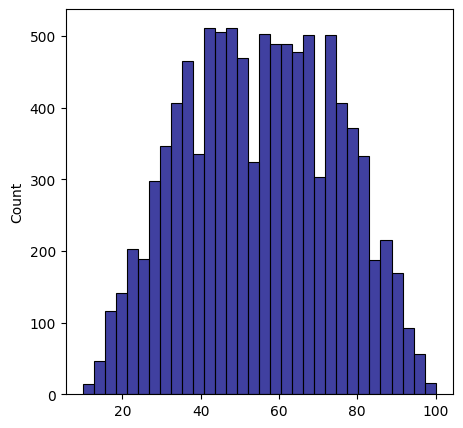

Avg: 55.2248


In [138]:
fig = plt.figure(figsize=(5, 5))
sns.histplot(y, color = "navy")
plt.show()
print('Avg:', sum(y)/len(y))

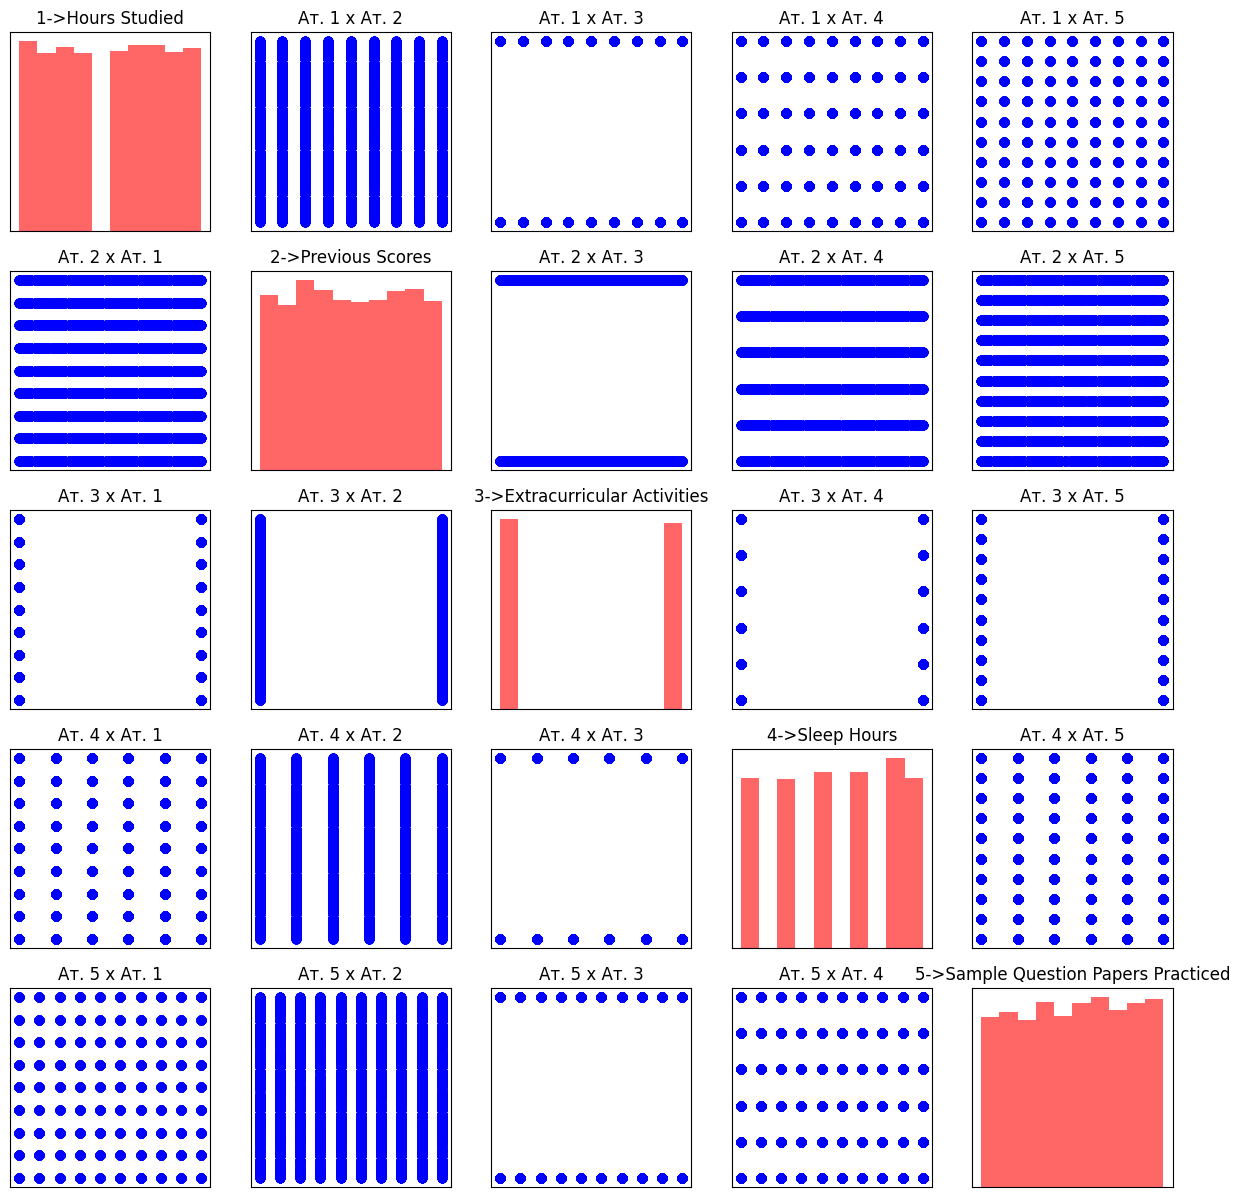

In [139]:
fig = plt.figure(figsize=(15, 15))
fig.subplots(nrows=number_of_features, ncols=number_of_features)
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        ax = plt.subplot(number_of_features,number_of_features,number_of_features*feature_i + feature_j+1)
        if feature_i==feature_j:
          plt.hist(X[:, feature_i], alpha=.6, color="red")
          plt.title(str(feature_i+1)+'->'+feature_names[feature_j])
        else:
          plt.scatter(X[:,feature_i], X[:,feature_j], color="blue")
          plt.title("Ат. "+str(feature_i+1)+" x Ат. "+str(feature_j+1)) # Атрибут i x Атрибут ј
          #plt.title(feature_names[feature_i] +" x "+feature_names[feature_j]) # Атрибут i x Атрибут ј
        plt.xticks(())
        plt.yticks(())
plt.show()

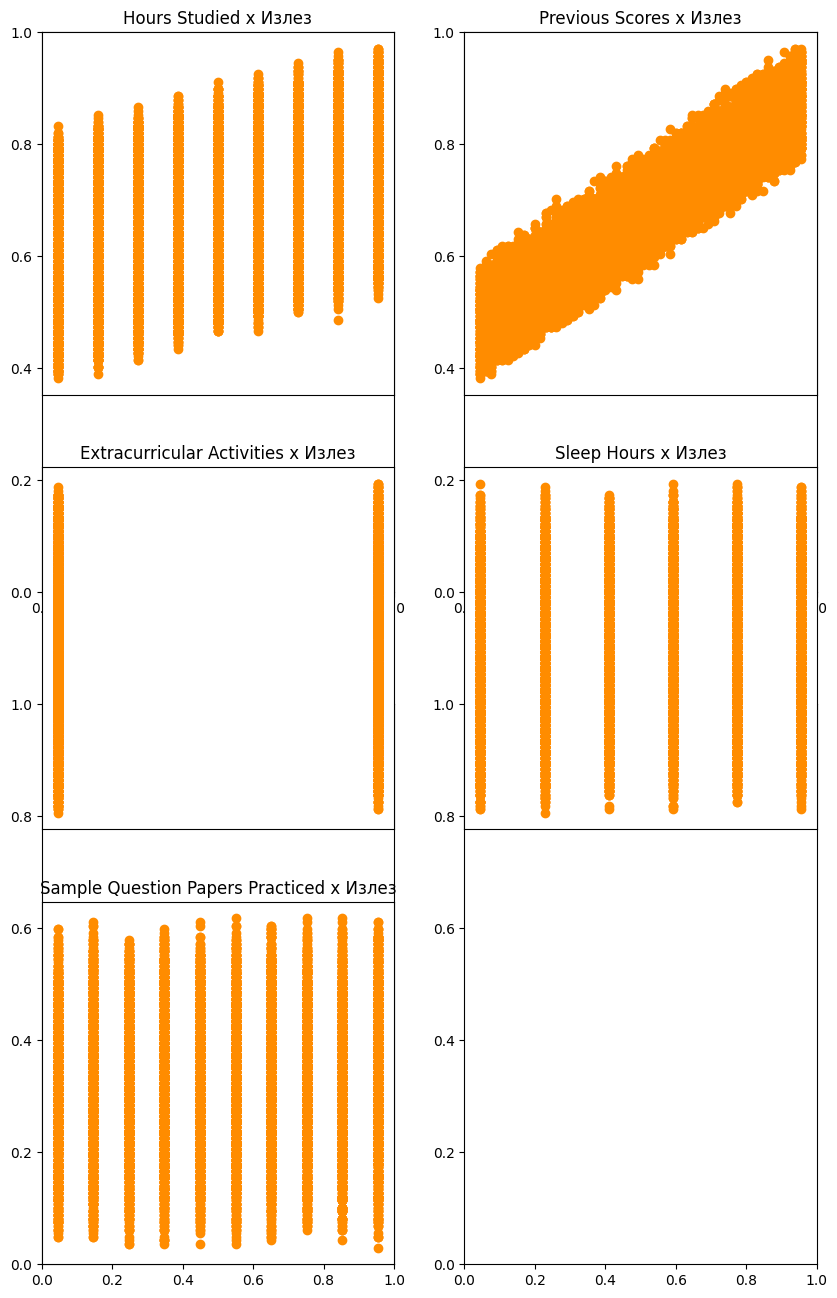

In [152]:
fig = plt.figure(figsize=(10, 16))
fig.subplots(nrows=(int)(number_of_features/2),ncols=2)
for feat_i in range(number_of_features):
    ax = plt.subplot(3,2, feat_i+1)
    plt.scatter( X[:,feat_i], y, color="darkorange")
    plt.xticks(())
    plt.yticks(())
    plt.title(str(feature_names[feat_i])+" x Излез")
plt.show()

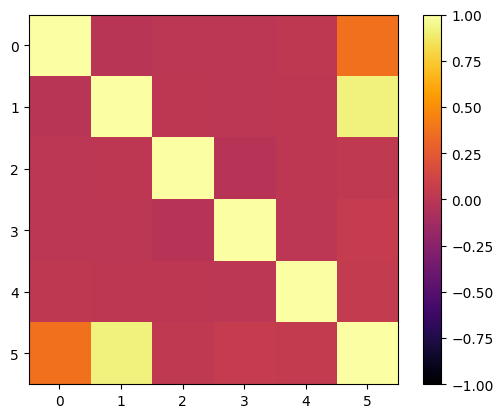

In [141]:
correlation_matrix = np.zeros((number_of_features+1,number_of_features+1))
# прво ги пресметуваме присоновите корелациски коефициенти за сите парови атрибути
for feature_i in range(number_of_features):
    for feature_j in range(number_of_features):
        corr, _ = stats.pearsonr(X[:,feature_i], X[:,feature_j])
        correlation_matrix[feature_i][feature_j] = corr
# потоа ги пресметуваме пирсоновите корелациски коефициенти за секој атрибут со целната променлива
for feature_i in range(number_of_features):
    target_i = number_of_features
    corr, _ = stats.pearsonr(X[:,feature_i], y)
    correlation_matrix[feature_i][target_i] = corr
    correlation_matrix[target_i][feature_i] = corr
# на крај го пресметуваме пирсоновиот корелациски коефициент за целната променлива само со себе (ова може и да се изостави зашто резултатот е 1)
corr, _ = stats.pearsonr(y, y)
correlation_matrix[target_i][target_i] = corr
corr, _ = stats.pearsonr(X[:,feature_i], y)

plt.figure()
plt.imshow(correlation_matrix, cmap = "inferno", vmin=-1, vmax=1) # ја исцртуваме матрицата со imshow
plt.colorbar()
plt.show()

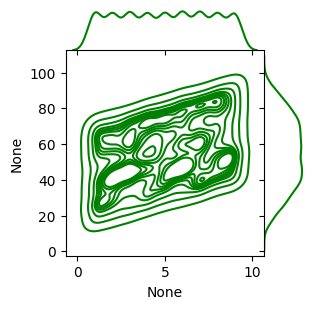

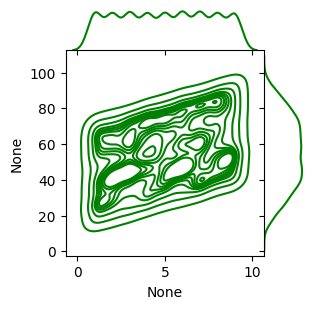

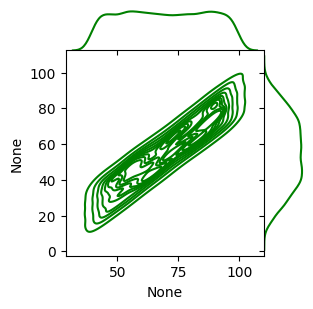

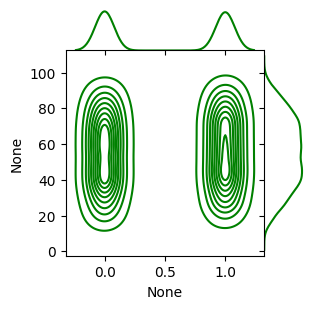

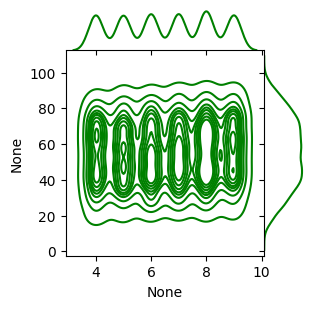

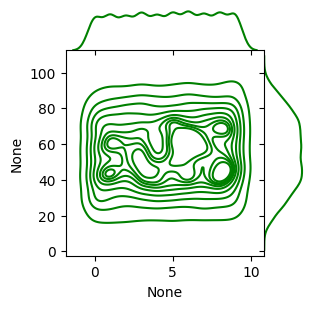

In [153]:
sns.jointplot(x=X[:,0], y=y, kind="kde", space=0, color="g", height = 3)
plt.show()
# откоментирајте го следниот код за приказ за секој атрибут
for feature_i in range(number_of_features):
    sns.jointplot(x=X[:,feature_i], y=y, kind="kde", space=0, color="g", height = 3)
plt.show()

# Regularizacija

In [143]:
scaler = MinMaxScaler()
tempX = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(tempX, y, test_size=0.30, random_state=42)


# Linearna regresija

Коефициенти W:  [22.87161784 59.91566786  0.58171285  2.3983838   1.71354741]
Пресек W0:  11.561907234173333
Средна квадратна грешка: 4.066563824092731
Средна апсолутна грешка: 1.609043756404535
Корен на средна квадратна грешка: 2.016572295776358
R-квадрат:  0.9890110607021135


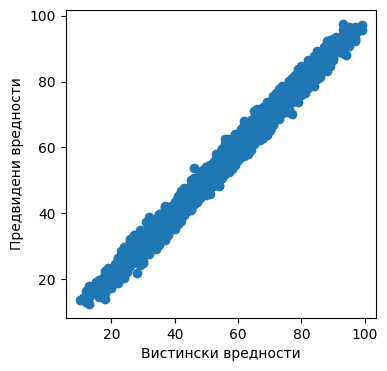

In [144]:
reg = LinearRegression().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# Ridge

Коефициенти W:  [22.86843696 59.90572891  0.58172688  2.39814839  1.71343262]
Пресек W0:  11.568650019951576
Средна квадратна грешка: 4.067464101023506
Средна апсолутна грешка: 1.609201344274803
Корен на средна квадратна грешка: 2.016795503025407
R-квадрат:  0.9890086279138993


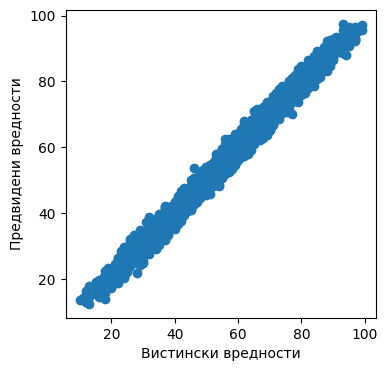

In [145]:

reg = RidgeCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# Lasso


Коефициенти W:  [22.8231988  59.85648033  0.56053228  2.35366443  1.66347289]
Пресек W0:  11.674543228323166
Средна квадратна грешка: 4.074405195319891
Средна апсолутна грешка: 1.610138142634165
Корен на средна квадратна грешка: 2.018515592042799
R-квадрат:  0.988989871227128


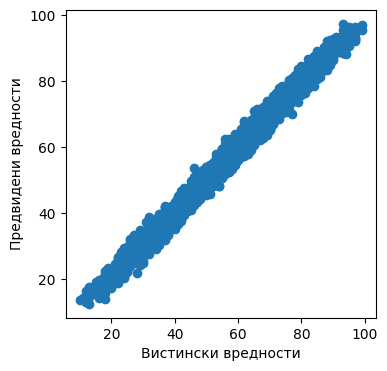

In [146]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
#klasifikatorot sam pravi selekcija na karakteristiki i regularizacija
reg = LassoCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()

# ElasticNetCV

Коефициенти W:  [21.73202284 56.4734999   0.56496641  2.27305744  1.62404549]
Пресек W0:  13.974443072329187
Средна квадратна грешка: 5.524655568601639
Средна апсолутна грешка: 1.8796757013444942
Корен на средна квадратна грешка: 2.3504585868722807
R-квадрат:  0.9850709081890191


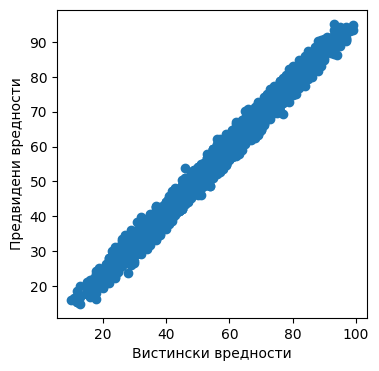

In [147]:
from sklearn.linear_model import ElasticNetCV
reg = ElasticNetCV().fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()


# ElasticNet


Коефициенти W:  [13.44387441 32.85620553  0.45701839  1.43647777  1.04628399]
Пресек W0:  30.727047192559276
Средна квадратна грешка: 78.2861966924332
Средна апсолутна грешка: 7.454933998546561
Корен на средна квадратна грешка: 8.847948727950067
R-квадрат:  0.7884498312263715


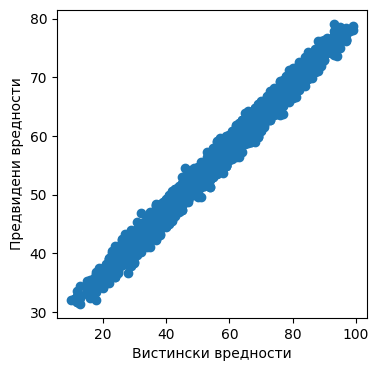

In [148]:
from sklearn.linear_model import ElasticNet
reg = ElasticNet(alpha = 0.1, l1_ratio = 0.3).fit(X_train, y_train)
print("Коефициенти W: ", reg.coef_)
print("Пресек W0: ", reg.intercept_)

y_pred = reg.predict(X_test) # предвиди ги вредностите на тест податоците
print("Средна квадратна грешка:", mean_squared_error(y_test, y_pred))
print("Средна апсолутна грешка:", mean_absolute_error(y_test, y_pred))
print("Корен на средна квадратна грешка:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R-квадрат: ", r2_score(y_test,y_pred)) # пресметај ја R - квадрат вредноста

# визуелизација на предвидените вредности од моделот
plt.figure(figsize=(4, 4))
plt.scatter(y_test,y_pred)
plt.xlabel("Вистински вредности")
plt.ylabel("Предвидени вредности")
plt.show()



# Sporedba


In [149]:

dat = data.values

tempX = X[:,[1]]

y = dat[:,-1]


N = tempX.shape[0]

# поставете модел на линеарна регресија
lr = LinearRegression() # иницијализација на моделот
lr.fit(tempX, y) # поставете го моделот на податоците
lrsigma = np.sum((y - lr.predict(tempX))**2) /(N-2) # пресметка на варијансата на моделот

# поставете модел на риџ регресија
ridge = RidgeCV()
ridge.fit(tempX, y)
ridgesigma = np.sum((y - ridge.predict(tempX))**2) /(N-2)

# поставете модел на ласо регресија
lasso = LassoCV()
lasso.fit(tempX, y)
lassosigma = np.sum((y - lasso.predict(tempX))**2) /(N-2)

# поставете модел на регресија на еластична мрежа
elastic = ElasticNet(alpha=0.1, l1_ratio = 0.4)
elastic.fit(tempX, y)
elasticsigma = np.sum((y - elastic.predict(tempX))**2) /(N-2)

# поставете модел на баесова риџ регресија
Bayes = BayesianRidge()
Bayes.fit(tempX, y)

print("Коефициенти на моделите")
print("Линеарна регресија: ",lr.coef_)
print("Риџ регресија: ", ridge.coef_)
print("Ласо регресија: ", lasso.coef_)
print("Еластична мрежа:", elastic.coef_)
print("Баесова риџ регресија: ", Bayes.coef_)

Коефициенти на моделите
Линеарна регресија:  [1.0138367]
Риџ регресија:  [1]
Ласо регресија:  [1.01282286]
Еластична мрежа: [1.01350151]
Баесова риџ регресија:  [1.01381704]


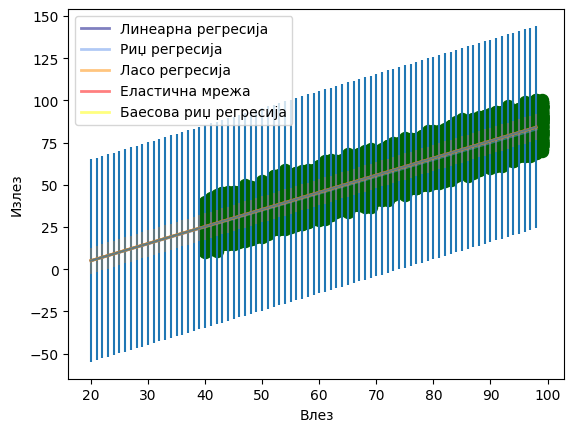

In [150]:
# пресметка на линијата на секој модел во опсег [20, X.max()]
line_X = np.arange(20, tempX.max())[:, np.newaxis]
line_y = lr.predict(line_X)
line_y_ridge = ridge.predict(line_X)
line_y_lasso = lasso.predict(line_X)
line_y_elastic = elastic.predict(line_X)
line_y_bayes, Bayessigma = Bayes.predict(line_X, return_std = True) # во баесовиот модел може да се пресмета варијансата за секоја предикција

lw = 2 # параметар за визуелизација (linewidth)
plt.figure() # ги цртаме податочните точки и ги цртаме линиите што ги претставуваат различните модели, ги цртаме и лентите за грешки на моделите за линеарна и баесова Ridge регресија
plt.scatter(tempX, y, color='darkgreen', marker='.', s = 300)
plt.plot(line_X, line_y, color='navy', linewidth=lw, label='Линеарна регресија', alpha=0.5)
plt.errorbar(line_X, line_y,yerr=lrsigma)
plt.plot(line_X, line_y_ridge, color='cornflowerblue', linewidth=lw, label='Риџ регресија', alpha=0.5)
plt.plot(line_X, line_y_lasso, color='darkorange', linewidth=lw, label='Ласо регресија', alpha=0.5)
plt.plot(line_X, line_y_elastic, color="red", linewidth=lw, label='Еластична мрежа', alpha=0.5)
plt.plot(line_X, line_y_bayes, color="yellow", linewidth=lw, label='Баесова риџ регресија', alpha=0.5)
plt.errorbar(line_X, line_y_bayes, yerr=Bayessigma, alpha = 0.3)

plt.legend(loc='best')
plt.xlabel("Влез")
plt.ylabel("Излез")
plt.show()

Обликот на X:  (10000, 5)
Обликот на Xt:  (10000, 2)
Коефициенти [linear_coef, quadratic_coef]:
Линеарна: [ 3.1036623  -0.03314315]
Риџ: [3 0]
Ласо: [2.60309928 0.01430795]
Еластична: [2.5374933  0.02076543]
Баесова: [ 3.04092394 -0.02716265]


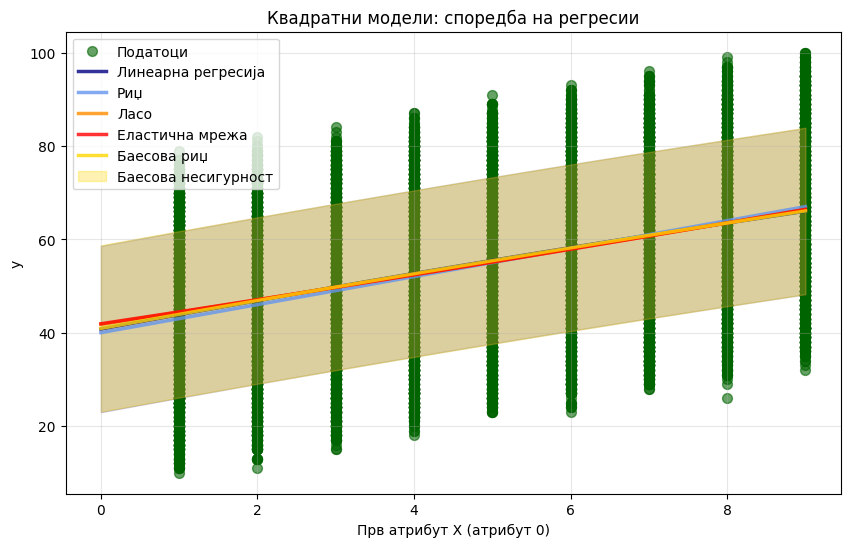

In [151]:
import numpy as np
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNet, BayesianRidge
import matplotlib.pyplot as plt

# Quadratic features on col0 only
Xt = np.column_stack([X[:, 0], X[:, 0]**2])  # [linear X0, quadratic X0^2]
print("Обликот на X: ", X.shape)
print("Обликот на Xt: ", Xt.shape)

# Train models
lr = LinearRegression().fit(Xt, y)
lrsigma = np.sqrt(np.sum((y - lr.predict(Xt))**2) / (N-2))

ridge = RidgeCV().fit(Xt, y)
ridgesigma = np.sqrt(np.sum((y - ridge.predict(Xt))**2) / (N-2))

lasso = LassoCV().fit(Xt, y)
lassosigma = np.sqrt(np.sum((y - lasso.predict(Xt))**2) / (N-2))

elastic = ElasticNet(alpha=0.1, l1_ratio=0.4).fit(Xt, y)
elasticsigma = np.sqrt(np.sum((y - elastic.predict(Xt))**2) / (N-2))

Bayes = BayesianRidge().fit(Xt, y)

print("Коефициенти [linear_coef, quadratic_coef]:")
print("Линеарна:", lr.coef_)
print("Риџ:", ridge.coef_)
print("Ласо:", lasso.coef_)
print("Еластична:", elastic.coef_)
print("Баесова:", Bayes.coef_)


x_range = np.linspace(0, np.max(X[:,0]), 100)[:, np.newaxis]  # Shape (100,1)
Xt_line = np.column_stack([x_range.flatten(), x_range.flatten()**2])  # (100,2)

line_y = lr.predict(Xt_line)
line_y_ridge = ridge.predict(Xt_line)
line_y_lasso = lasso.predict(Xt_line)
line_y_elastic = elastic.predict(Xt_line)
line_y_bayes, Bayessigma = Bayes.predict(Xt_line, return_std=True)


lw = 2.5
plt.figure(figsize=(10,6))
plt.scatter(X[:,0], y, color='darkgreen', marker='.', s=200, alpha=0.6, label='Податоци')
plt.plot(x_range, line_y, 'navy', lw=lw, label='Линеарна регресија', alpha=0.8)
plt.fill_between(x_range.flatten(), line_y-lrsigma, line_y+lrsigma, color='navy', alpha=0.2)
plt.plot(x_range, line_y_ridge, 'cornflowerblue', lw=lw, label='Риџ', alpha=0.8)
plt.plot(x_range, line_y_lasso, 'darkorange', lw=lw, label='Ласо', alpha=0.8)
plt.plot(x_range, line_y_elastic, 'red', lw=lw, label='Еластична мрежа', alpha=0.8)
plt.plot(x_range, line_y_bayes, 'gold', lw=lw, label='Баесова риџ', alpha=0.8)
plt.fill_between(x_range.flatten(), line_y_bayes-Bayessigma.flatten(), line_y_bayes+Bayessigma.flatten(), 
                 color='gold', alpha=0.3, label='Баесова несигурност')
plt.xlabel("Прв атрибут X (атрибут 0)")
plt.ylabel("y")
plt.title("Квадратни модели: споредба на регресии")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()
